# OpenMesh Example Notebook

Download, explore and analyse the **OpenMesh** dataset with the
[OpenSense](https://github.com/OpenSenseAction) ecosystem.

| Resource | Link |
|---|---|
| Data — CML (Zenodo) | https://doi.org/10.5281/zenodo.15287692 |
| Data — PWS (Zenodo) | https://doi.org/10.5281/zenodo.17508286 |
| Paper (ESSD) | https://doi.org/10.5194/essd-2025-238 |
| Code (GitHub) | https://github.com/drorjac/OpenMesh |

**Three complementary sources:**

| Dataset | Source | Description |
|---------|--------|-------------|
| **CML** | NYC Mesh | RSL time-series — 75 links, 3 sublinks each |
| **ASOS** | NOAA | Official 1-min reference rain gauges (JFK, LGA, NYC) |
| **PWS** | Weather Underground | Crowdsourced personal weather stations |

**OpenSense packages used:** [`poligrain`](https://github.com/OpenSenseAction/poligrain) (CML plotting),
[`pypwsqc`](https://github.com/OpenSenseAction/pypwsqc) (PWS QC),
[`xarray`](https://docs.xarray.dev), `matplotlib`, `pyproj`

## Installation

In [61]:
# Uncomment to install
# !pip install poligrain pypwsqc xarray netCDF4 requests tqdm pyproj matplotlib numpy pandas scipy

## Imports

In [62]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyproj import Geod

import poligrain as plg


import openmesh_data_io as omio
import ws_opensense_conversion as wsoc

warnings.filterwarnings("ignore")
%matplotlib inline

print(f"poligrain : {plg.__version__}")
print(f"xarray    : {xr.__version__}")

poligrain : 0.3.1
xarray    : 2025.9.1


---

## Download datasets

Download CML and PWS datasets from their respective Zenodo records (skips if already present):
- **CML**: https://doi.org/10.5281/zenodo.15287692
- **PWS**: https://doi.org/10.5281/zenodo.17508286

Then extract a sample for the chosen time window.

In [63]:
SAMPLE_DIR     = omio.SAMPLE_DIR
ASOS_META_PATH = wsoc.ASOS_META_PATH
print(f"Data dir: {omio.DATA_DIR}")

# Download from Zenodo — skips if files already present
omio.download_openmesh()   # → notebooks/data/raw/ds_openmesh.nc
omio.download_pws_wu()     # → notebooks/data/raw/pws_wu_os.nc


Data dir: /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh
  CML found locally  : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/ds_openmesh.nc
  PWS found locally  : /Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc


PosixPath('/Users/drorjac/PycharmProjects/opensense_example_data_openmesh/OpenMesh/notebooks/data/jacoby_2025_OpenMesh/raw/pws_wu_os.nc')

In [64]:
# Paths to pre-built example files in the main OpenMesh folder
ROOT_DIR  = Path("../")
CML_FILE  = ROOT_DIR / "openmesh_cml_20d.nc"
PWS_FILE  = ROOT_DIR / "openmesh_wu_pws_20d.nc"
ASOS_FILE = ROOT_DIR / "openmesh_asos_ws_20d.nc"
# ── Mode ────────────────────────────────────────────
# Set READ_FROM_FILES = True to load existing .nc files from the main folder,
READ_FROM_FILES = True

if READ_FROM_FILES:
    ds_cmls = xr.open_dataset(CML_FILE)
    ds_pws  = xr.open_dataset(PWS_FILE)
    ds_asos = xr.open_dataset(ASOS_FILE)

    print(f"Loaded CML : {CML_FILE}")
    print(f"Loaded PWS : {PWS_FILE}")
    print(f"Loaded ASOS: {ASOS_FILE}")

# lon/lat are NaN in the pre-built file (ID mismatch in the creation pipeline:
# data uses short IDs like "JFK" but the metadata CSV uses ICAO IDs like "KJFK").
# Assign the known station coordinates so spatial operations work correctly.
ASOS_COORDS = {
    "JFK": (40.6386, -73.7622),
    "EWR": (40.6925, -74.1687),
    "LGA": (40.7794, -73.8803),
    "NYC": (40.7790, -73.9690),
}
ds_asos = ds_asos.assign_coords(
    lat=("id", [ASOS_COORDS[s][0] for s in ds_asos.id.values]),
    lon=("id", [ASOS_COORDS[s][1] for s in ds_asos.id.values]),
)


Loaded CML : ../openmesh_cml_20d.nc
Loaded PWS : ../openmesh_wu_pws_20d.nc
Loaded ASOS: ../openmesh_asos_ws_20d.nc


In [65]:
CREATE_DATA = False
if CREATE_DATA:
    # Create samples for a specific time window.
    START_TIME = "2024-01-15"
    END_TIME   = "2024-01-30"

    datasets = omio.create_all_datasets(
        start_time=START_TIME,
        end_time=END_TIME,
        save=True,
    )
    ds_cmls = datasets["cml"]
    ds_pws  = datasets["pws"]
    ds_asos = datasets["asos"]

---

## CML Data — Microwave Link Signal Levels

### Dataset structure

OpenSense v1.0 format — dims `(cml_id, sublink_id, time)`.

In [66]:
print(ds_cmls)

t0  = pd.Timestamp(ds_cmls.time.values[0])
t1  = pd.Timestamp(ds_cmls.time.values[-1])
dt  = (ds_cmls.time.values[1] - ds_cmls.time.values[0]) / np.timedelta64(1, "s")
print(f"\n{ds_cmls.sizes}  |  {t0.date()} → {t1.date()}  |  {dt:.0f} s  |  vars: {list(ds_cmls.data_vars)}")

<xarray.Dataset> Size: 26MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 28801)
Coordinates:
  * time          (time) datetime64[ns] 230kB 2024-01-12 ... 2024-02-01
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B ...
    site_0_lon    (cml_id) float32 300B ...
    site_1_lat    (cml_id) float32 300B ...
    site_1_lon    (cml_id) float32 300B ...
    length        (cml_id) float32 300B ...
    frequency     (cml_id, sublink_id) float32 900B ...
    polarization  (cml_id, sublink_id) object 2kB ...
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 26MB ...
Attributes: (12/15)
    title:                 OpenMesh CML sample (20d), start 2024-01-12
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:  

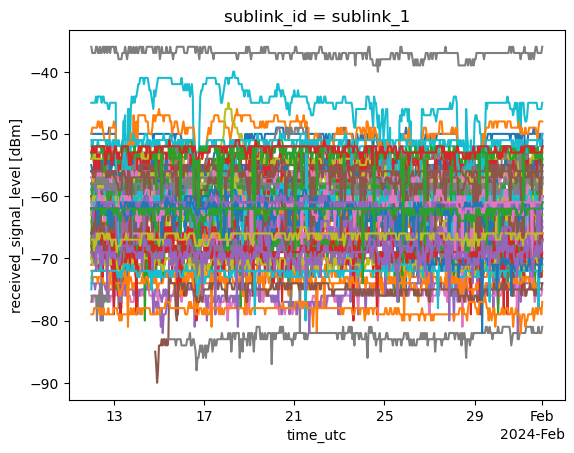

In [67]:
ds_cmls.rsl.isel(sublink_id=0).resample(time='1h').min().plot.line(x='time', add_legend=False);

### Frequency & polarization distribution

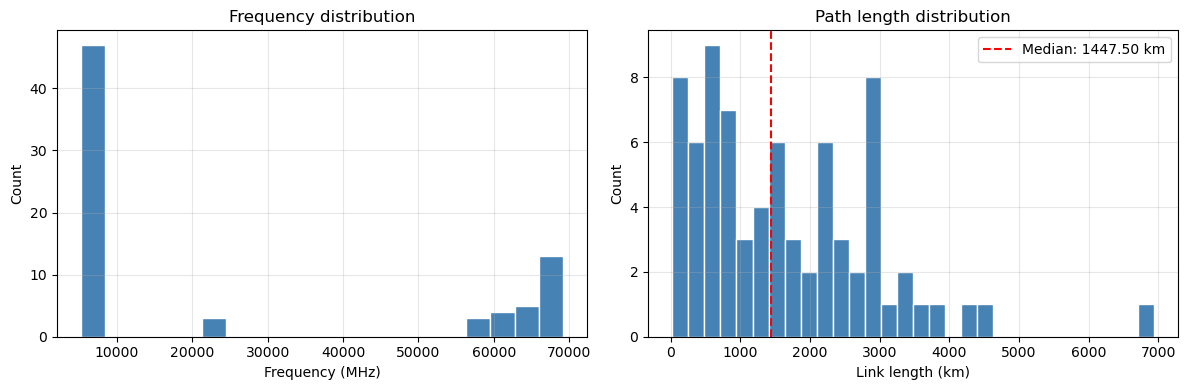

Frequency  : 5270 – 69120 MHz  |  unique: [ 5270.  5280.  5300.  5310.  5490.  5500.  5505.  5510.  5545.  5550.
  5560.  5570.  5700.  5710.  5750.  5760.  5770.  5795.  5810.  5815.
  5825. 24100. 24200. 58320. 60480. 62640. 64800. 65880. 68040. 69120.]
Length     : 24.50 – 6936.50 km  |  median: 1447.50 km


In [68]:
freq_vals = ds_cmls.frequency.isel(sublink_id=0).values
freq_vals = freq_vals[~np.isnan(freq_vals)]
lengths_km = ds_cmls.length.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(freq_vals,  bins=20, color="steelblue", edgecolor="white")
axes[0].set(xlabel="Frequency (MHz)", ylabel="Count", title="Frequency distribution")

axes[1].hist(lengths_km, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(np.median(lengths_km), color="red", linestyle="--",
                label=f"Median: {np.median(lengths_km):.2f} km")
axes[1].set(xlabel="Link length (km)", ylabel="Count", title="Path length distribution")
axes[1].legend()

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Frequency  : {freq_vals.min():.0f} – {freq_vals.max():.0f} MHz  |  unique: {np.unique(freq_vals)}")
print(f"Length     : {lengths_km.min():.2f} – {lengths_km.max():.2f} km  |  median: {np.median(lengths_km):.2f} km")

### CML network map

`poligrain.scatter_lines()` draws CML paths colored by frequency.

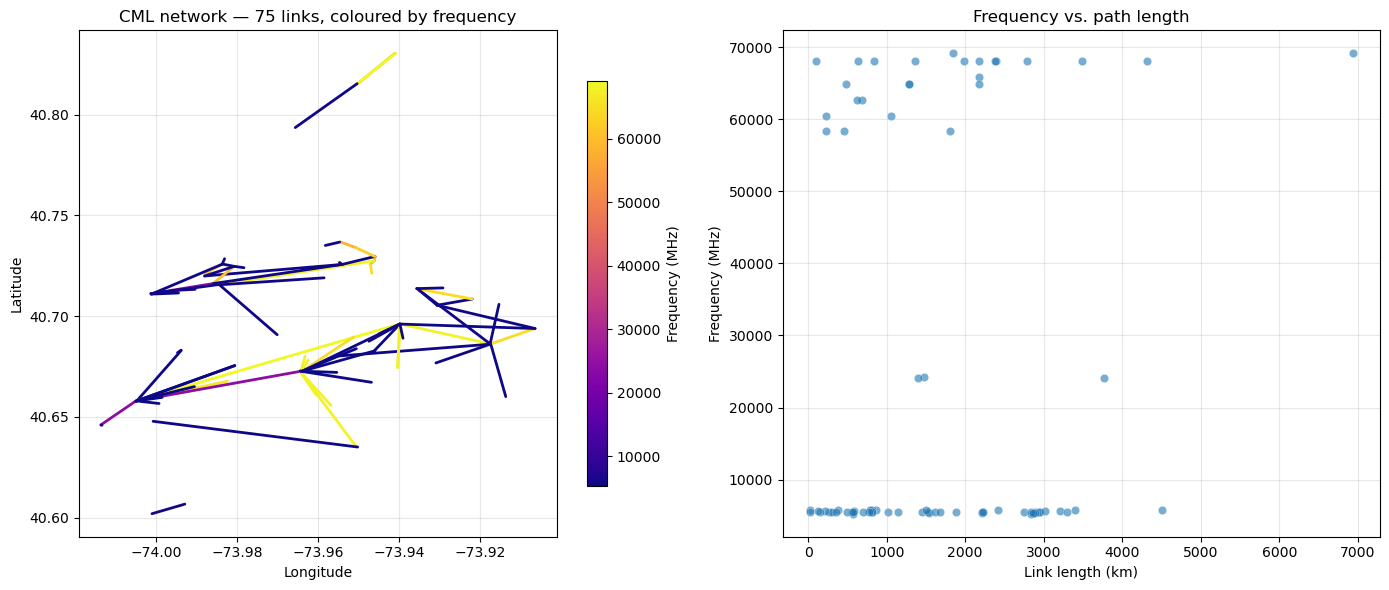

In [69]:
x0, y0 = ds_cmls.site_0_lon.values, ds_cmls.site_0_lat.values
x1, y1 = ds_cmls.site_1_lon.values, ds_cmls.site_1_lat.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lc = plg.plot_map.scatter_lines(
    x0=x0, y0=y0, x1=x1, y1=y1,
    c=ds_cmls.frequency.isel(sublink_id=0).values,
    s=2, cmap=plt.cm.plasma, ax=axes[0],
)
plt.colorbar(lc, ax=axes[0], label="Frequency (MHz)", shrink=0.8)
axes[0].set(xlabel="Longitude", ylabel="Latitude",
            title=f"CML network — {len(x0)} links, coloured by frequency")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(lengths_km, freq_vals, alpha=0.6, edgecolors="white", linewidths=0.3)
axes[1].set(xlabel="Link length (km)", ylabel="Frequency (MHz)",
            title="Frequency vs. path length")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Data availability

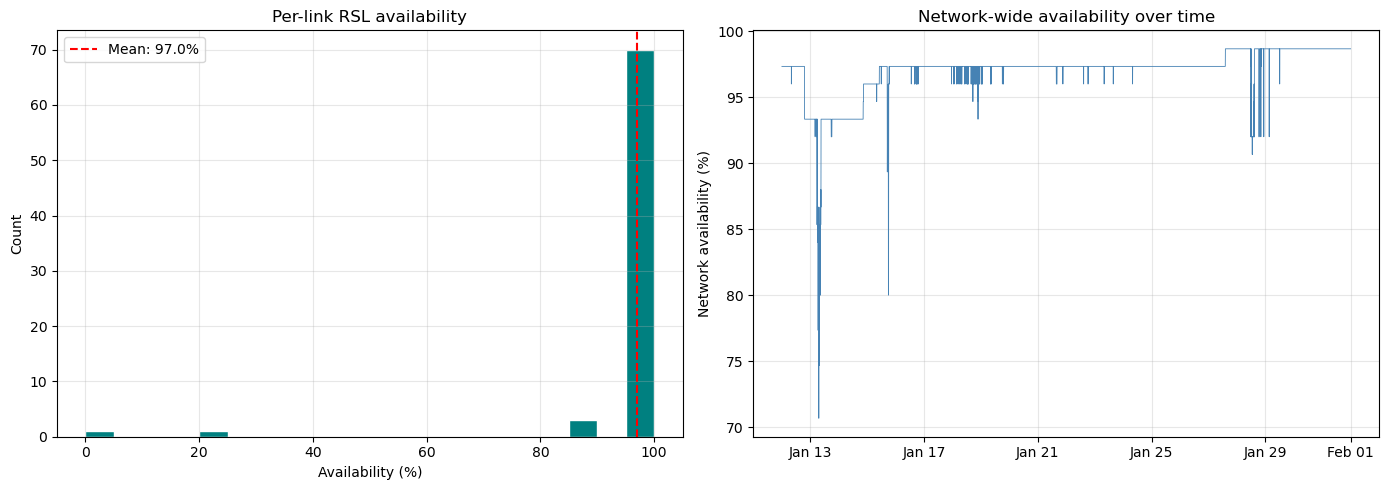

Mean availability : 97.0%  |  >80%: 73 / 75 links


In [70]:
rsl = ds_cmls["rsl"].isel(sublink_id=0)
valid = ~np.isnan(rsl)
avail_link = valid.mean(dim="time").values
avail_time = valid.mean(dim="cml_id")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(avail_link * 100, bins=20, color="teal", edgecolor="white")
axes[0].axvline(avail_link.mean() * 100, color="red", linestyle="--",
                label=f"Mean: {avail_link.mean()*100:.1f}%")
axes[0].set(xlabel="Availability (%)", ylabel="Count", title="Per-link RSL availability")
axes[0].legend()

axes[1].plot(pd.DatetimeIndex(avail_time.time.values), avail_time.values * 100,
             color="steelblue", linewidth=0.6)
axes[1].set(ylabel="Network availability (%)", title="Network-wide availability over time")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean availability : {avail_link.mean()*100:.1f}%  |  "
      f">80%: {(avail_link > 0.8).sum()} / {ds_cmls.sizes['cml_id']} links")

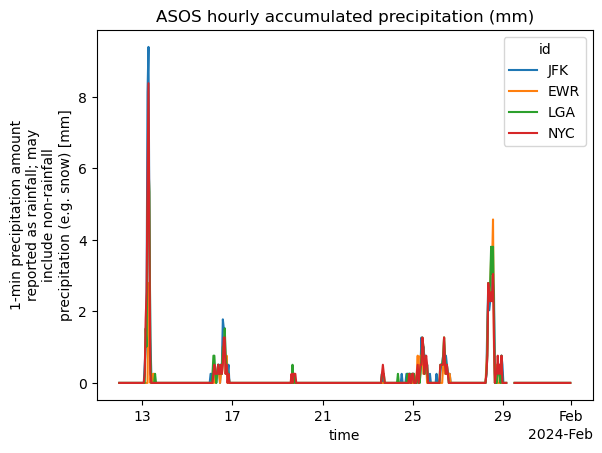

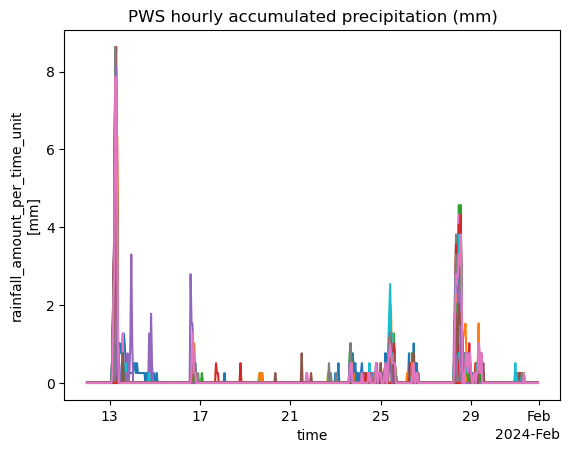

In [71]:
# QC — remove implausible outliers (top 0.1% of values) from both networks
ds_asos["rainfall_amount"] = ds_asos["rainfall_amount"].where(ds_asos["rainfall_amount"] <= ds_asos["rainfall_amount"].quantile(0.999))
ds_pws["rainfall_amount"] = ds_pws["rainfall_amount"].where(ds_pws["rainfall_amount"] <= ds_pws["rainfall_amount"].quantile(0.999))

ds_asos["rainfall_amount"].resample(time="1h").sum(skipna=True).plot.line(x="time", add_legend=True)
plt.title("ASOS hourly accumulated precipitation (mm)");
plt.show()

ds_pws["rainfall_amount"].resample(time="1h").sum(skipna=True).plot.line(x="time", add_legend=False)
plt.title("PWS hourly accumulated precipitation (mm)");
plt.show()

In [72]:
# remove sentinel values (-99 is a known fill value in the dataset)
ds_cmls["rsl"] = ds_cmls.rsl.where(ds_cmls.rsl > -99)

dt_h   = (pd.Timestamp(ds_cmls.time.values[1]) - pd.Timestamp(ds_cmls.time.values[0])).total_seconds() / 3600
win_5h = round(5 / dt_h)   # timesteps in 5 h — diurnal window
win_2h = round(2 / dt_h)   # timesteps in 2 h — noise window

# diurnal: signal fluctuates in a daily cycle (sun heating antenna) — not rain
qc_diurnal = (ds_cmls.rsl.rolling(time=win_5h, center=True).std() > 2).mean(dim="time") > 0.1

# noisy: signal is randomly unstable for long periods — hardware or interference issue
qc_noisy = (ds_cmls.rsl.rolling(time=win_2h, center=True).std() > 0.8).mean(dim="time") > 0.2

# null bad sublinks, keep the CML structure intact
qc_bad = qc_diurnal | qc_noisy
ds_cmls_clean = ds_cmls.copy()
ds_cmls_clean["rsl"] = ds_cmls.rsl.where(~qc_bad)

# count only sublinks that actually have data
n_total   = int((~ds_cmls.rsl.isnull().all(dim="time")).sum().values)
n_diurnal = int(qc_diurnal.sum().values)
n_noisy   = int(qc_noisy.sum().values)
n_bad     = int(qc_bad.sum().values)
print(f"Total sublinks   : {n_total}")
print(f"Flagged diurnal  : {n_diurnal}")
print(f"Flagged noisy    : {n_noisy}")
print(f"Flagged (either) : {n_bad}")
print(f"Clean sublinks   : {n_total - n_bad}")

Total sublinks   : 100
Flagged diurnal  : 5
Flagged noisy    : 34
Flagged (either) : 35
Clean sublinks   : 65


### Excess attenuation

$$A = \mathrm{RSL_{baseline}} - \mathrm{RSL}$$

Baseline = dry-weather RSL reference estimated by the chosen method (see above). Positive $A$ → signal drop → rain.

### Baseline estimation

Four methods are available to estimate the RSL baseline (dry reference level):

- **`rolling`** — rolling median over the window; no wet/dry classification needed
- **`std`** — wet periods detected via fixed rolling std threshold; baseline fitted on dry periods
- **`std_adaptive`** — same as `std` but threshold adapts per-link to its own std distribution
- **`ref_asos`** — wet periods derived from ASOS network mean precipitation; most accurate when reference data is available

Set `BASELINE` below to choose the method.

In [73]:
import pycomlink as pycml

BASELINE      = "ref_asos"  # see description above
WINDOW_HOURS  = 6    # window duration for all methods
WET_STD       = 0.4  # std threshold for "std" method (dB)
WET_THRESHOLD = 0.1  # mm/window for "ref_asos" method
N_DRY         = 10   # dry samples averaged at wet event start

In [74]:
dt_h   = (pd.Timestamp(ds_cmls.time.values[1]) - pd.Timestamp(ds_cmls.time.values[0])).total_seconds() / 3600
WINDOW = round(WINDOW_HOURS / dt_h)

def _apply_baseline(rsl, wet):
    return xr.apply_ufunc(
        pycml.processing.baseline.baseline_constant,
        rsl, wet.broadcast_like(rsl),
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        kwargs={"n_average_last_dry": N_DRY},
    )

# ── baseline ──────────────────────────────────────────────────
if BASELINE == "rolling":
    ds_cmls["baseline"] = ds_cmls.rsl.rolling(
        time=WINDOW, center=True, min_periods=WINDOW // 2
    ).median()

elif BASELINE == "std":
    ds_cmls["wet"]      = ds_cmls.rsl.rolling(time=WINDOW, center=True).std() > WET_STD
    ds_cmls["baseline"] = _apply_baseline(ds_cmls.rsl, ds_cmls.wet)

elif BASELINE == "std_adaptive":
    roll_std            = ds_cmls.rsl.rolling(time=WINDOW, center=True).std()
    ds_cmls["wet"]      = roll_std > 1.1 * roll_std.quantile(0.85, dim="time")
    ds_cmls["baseline"] = _apply_baseline(ds_cmls.rsl, ds_cmls.wet)

elif BASELINE == "ref_asos":
    rain_mean  = ds_asos["rainfall_amount"].resample(time="15min").sum(skipna=True).mean(dim="id", skipna=True)
    wet_asos   = (rain_mean > WET_THRESHOLD).rolling(time=3, center=True).max()
    wet_on_cml = wet_asos.astype(int).interp(time=ds_cmls.time, method="nearest").fillna(0).astype(bool)
    ds_cmls["wet"]      = wet_on_cml
    ds_cmls["baseline"] = _apply_baseline(ds_cmls.rsl, wet_on_cml)

print(f"Baseline: {BASELINE}  |  window: {WINDOW_HOURS}h = {WINDOW} samples")

Baseline: ref_asos  |  window: 6h = 360 samples


In [75]:
# ── config ───────────────────────────────────────────────────
R_MIN   = 0.1    #  rain rates below this are set to zero

# ── observed attenuation ─────────────────────────────────────
ds_cmls["A_obs"] = ds_cmls["baseline"] - ds_cmls.rsl
ds_cmls["A_obs"] = ds_cmls.A_obs.where(ds_cmls.A_obs >= 0, 0)

# ── wet antenna correction (optional) ────────────────────────

ds_cmls["waa"] = pycml.processing.wet_antenna.waa_pastorek_2021_from_A_obs(
    A_obs=ds_cmls.A_obs,
    f_Hz=ds_cmls.frequency * 1e6,
    pol=ds_cmls.polarization.values,
    L_km=ds_cmls.length / 1000,
)
ds_cmls["A"] = ds_cmls.A_obs - ds_cmls.waa


ds_cmls["A"] = ds_cmls.A.where(ds_cmls.A >= 0, 0)

# ── rain rate from k-R power law ─────────────────────────────
ds_cmls["R"] = pycml.processing.k_R_relation.calc_R_from_A(
    A=ds_cmls.A,
    L_km=ds_cmls.length.astype(float) / 1000,
    f_GHz=ds_cmls.frequency / 1000,
    pol=ds_cmls.polarization,
    R_min=R_MIN,
)

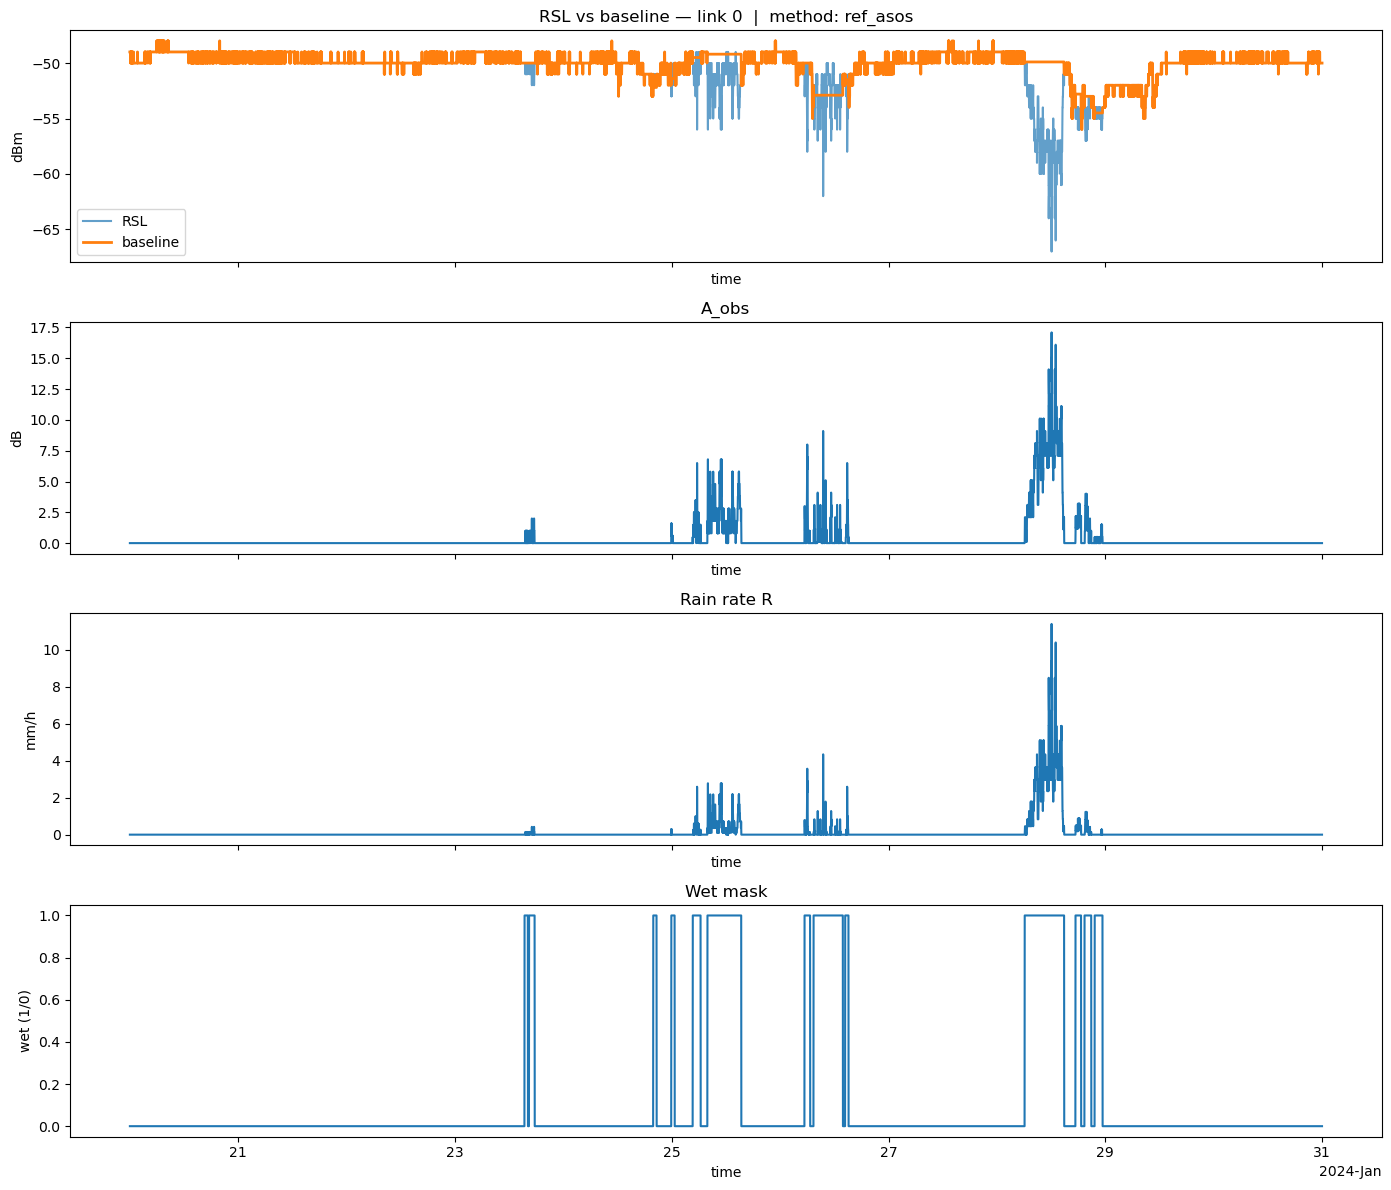

In [76]:
# ── baseline inspection — adjust link_idx and time window to evaluate params ──
link_idx = 0
t_check  = slice("2024-01-20", "2024-01-30")

n_panels = 3 + ("wet" in ds_cmls)
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), sharex=True)

ds_cmls.rsl.isel(cml_id=link_idx, sublink_id=0).sel(time=t_check).plot(
    ax=axes[0], label="RSL", alpha=0.7)
ds_cmls.baseline.isel(cml_id=link_idx, sublink_id=0).sel(time=t_check).plot(
    ax=axes[0], label="baseline", linewidth=2)
axes[0].set(title=f"RSL vs baseline — link {link_idx}  |  method: {BASELINE}", ylabel="dBm")
axes[0].legend()

ds_cmls.A_obs.isel(cml_id=link_idx, sublink_id=0).sel(time=t_check).plot(ax=axes[1])
axes[1].set(title="A_obs", ylabel="dB")

ds_cmls.R.isel(cml_id=link_idx, sublink_id=0).sel(time=t_check).plot(ax=axes[2])
axes[2].set(title="Rain rate R", ylabel="mm/h")

if "wet" in ds_cmls:
    ds_cmls.wet.sel(time=t_check).plot(ax=axes[3])
    axes[3].set(title="Wet mask", ylabel="wet (1/0)")

plt.tight_layout();

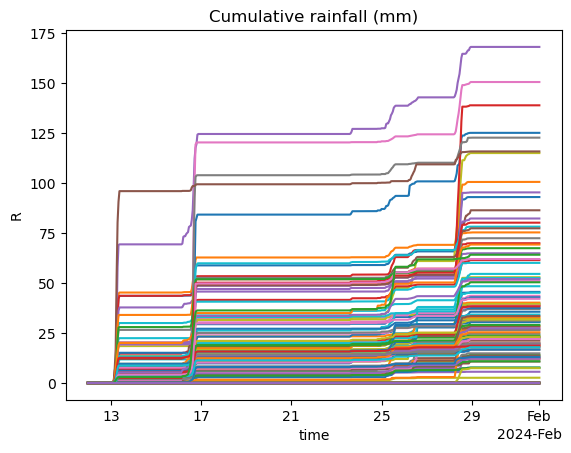

In [77]:
ds_cmls.R.resample(time="1h").mean().cumsum(dim="time").stack(link=("cml_id", "sublink_id")).plot.line(x="time", add_legend=False)
plt.title("Cumulative rainfall (mm)");

In [94]:
# ── filter options — set to None to skip ─────────────────────
LENGTH_KM  = (1, 10)   # min/max link length
FREQ_GHZ   = (65.0, 70.0)  # min/max frequency

# ── build mask — True = keep ──────────────────────────────────
mask = xr.ones_like(ds_cmls.rsl.isel(time=0), dtype=bool)

### filter by link length and frequency
if LENGTH_KM  is not None: mask = mask & (ds_cmls.length    >= LENGTH_KM[0] * 1000) & (ds_cmls.length    <= LENGTH_KM[1] * 1000)
if FREQ_GHZ   is not None: mask = mask & (ds_cmls.frequency >= FREQ_GHZ[0]  * 1000) & (ds_cmls.frequency <= FREQ_GHZ[1]  * 1000)

### filter by QC flags
DROP_NOISY    = True
DROP_DIURNAL  = False

if DROP_NOISY:    mask = mask & ~qc_noisy
if DROP_DIURNAL:  mask = mask & ~qc_diurnal

ds_cmls_filtered = ds_cmls.where(mask)

print(f"Sublinks kept : {int(mask.sum().values)} / {ds_cmls.sizes['cml_id'] * ds_cmls.sizes['sublink_id']}")
print(f"CMLs with at least one valid sublink : {int(mask.any(dim='sublink_id').sum().values)} / {ds_cmls.sizes['cml_id']}")

Sublinks kept : 13 / 225
CMLs with at least one valid sublink : 10 / 75


Text(0.5, 1.0, 'PL Rain Estimation')

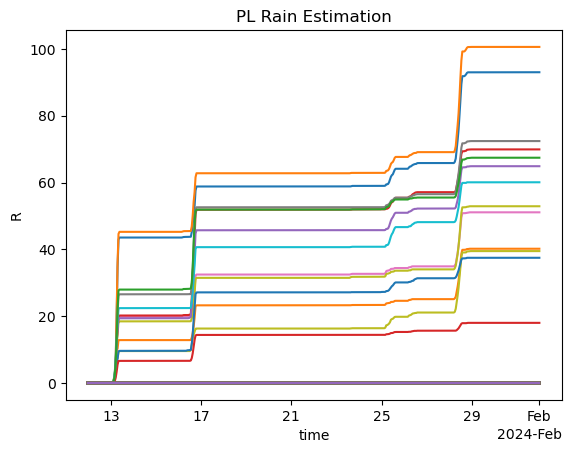

In [97]:
ds_cmls_filtered.R.resample(time="1h").mean().cumsum(dim="time").stack(link=("cml_id", "sublink_id")).plot.line(x="time", add_legend=False);

plt.title('PL Rain Estimation')

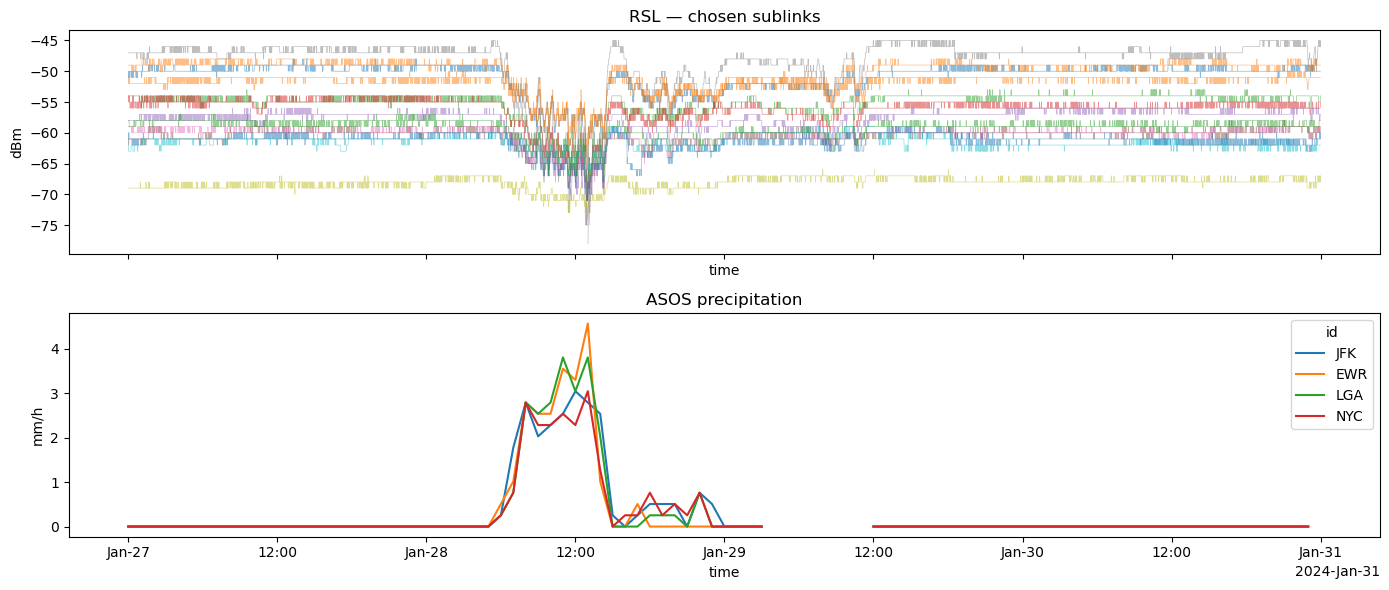

In [80]:
t_check = slice("2024-01-27", "2024-01-30")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ds_cmls_filtered.rsl.sel(time=t_check).stack(link=("cml_id", "sublink_id")).dropna("link", how="all").plot.line(
    x="time", ax=axes[0], add_legend=False, linewidth=0.5, alpha=0.5)
axes[0].set(ylabel="dBm", title="RSL — chosen sublinks")

ds_asos["rainfall_amount"].resample(time="1h").sum().sel(time=t_check).plot.line(
    x="time", ax=axes[1], add_legend=True)
axes[1].set(ylabel="mm/h", title="ASOS precipitation")

plt.tight_layout();

---

## Personal Weather Station (PWS) Data

PWS data from Weather Underground provides dense crowdsourced rainfall observations
across NYC. Consumer-grade stations require quality control before use.

### Dataset Overview

Stations > 80% availability : 27 / 37
Stations > 50% availability : 30 / 37


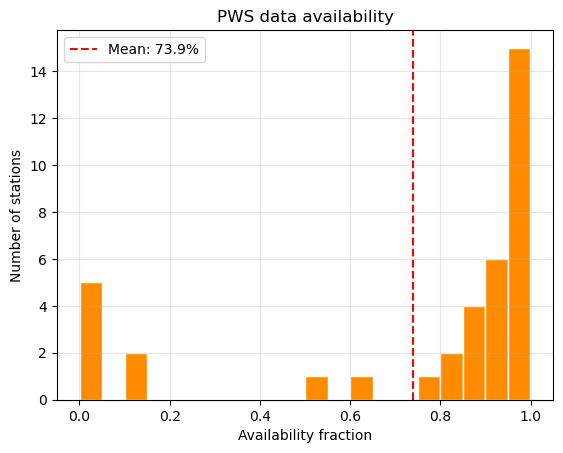

In [81]:
# data availability per station — fraction of non-NaN timesteps
avail = (~np.isnan(ds_pws["rainfall_amount"])).mean(dim="time")

avail.plot.hist(bins=20, color="darkorange", edgecolor="white")
plt.axvline(float(avail.mean()), color="red", linestyle="--",
            label=f"Mean: {float(avail.mean())*100:.1f}%")
plt.title("PWS data availability")
plt.xlabel("Availability fraction")
plt.ylabel("Number of stations")
plt.legend()
plt.grid(True, alpha=0.3);

print(f"Stations > 80% availability : {int((avail > 0.8).sum())} / {ds_pws.sizes['id']}")
print(f"Stations > 50% availability : {int((avail > 0.5).sum())} / {ds_pws.sizes['id']}")

### Quality Control with `pypwsqc`

[`pypwsqc`](https://github.com/OpenSenseAction/pypwsqc) implements QC methods
| Filter | What it catches |
|--------|----------------|
| **Faulty Zero (FZ)** | Station reports zero while neighbours report rain |
| **Suspect Zero (SZ)** | Suspiciously few non-zero readings overall |
| **High Accumulation (HA)** | Implausibly large values |

In [82]:
import pypwsqc
print(f"pypwsqc   : {pypwsqc.__version__}")

pypwsqc   : 0.2.1


In [83]:
import pypwsqc.peak_removal_filter as prf

from pypwsqc import peak_removal_filter as prf
# ── 0. availability — drop stations with too little data ──────
MIN_AVAIL = 0.5   # keep stations with at least 50% valid data
avail     = (~np.isnan(ds_pws["rainfall_amount"])).mean(dim="time")
ds_pws    = ds_pws.sel(id=avail[avail >= MIN_AVAIL].id)
print(f"[0] Availability filter : {ds_pws.sizes['id']} stations kept  (>= {MIN_AVAIL*100:.0f}%)")

# ── 1. quantile — remove implausible values ───────────────────
ds_pws["rainfall_amount"] = ds_pws["rainfall_amount"].where(
    ds_pws["rainfall_amount"] <= ds_pws["rainfall_amount"].quantile(0.999)
).assign_attrs(ds_pws["rainfall_amount"].attrs)
print(f"[1] Quantile filter     : top 0.1% values removed")

# ── project to UTM (needed by peak removal and IC filter) ───
ds_pws = prf.convert_to_utm(ds_pws, name_coord_lon="lon", name_coord_lat="lat", zone=18)
print(f"[+] UTM projection      : x/y coords added")


[0] Availability filter : 30 stations kept  (>= 50%)
[1] Quantile filter     : top 0.1% values removed
[+] UTM projection      : x/y coords added


In [84]:
# ── 2. FZ + HI flagging ───────────────────────────────────────
NINT, N_STAT, HI_THRES_A, HI_THRES_B = 10, 3, 0.5, 2.0
rain    = ds_pws["rainfall_amount"]
ref     = rain.median(dim="id", skipna=True)
nbrs_nn = (~np.isnan(rain)).sum(dim="id").broadcast_like(rain)
ds_qc   = xr.Dataset({"rainfall": rain, "reference": ref.broadcast_like(rain),
                       "nbrs_not_nan": nbrs_nn.astype(float)})
ds_qc   = pypwsqc.flagging.hi_filter(ds_qc, hi_thres_a=HI_THRES_A, hi_thres_b=HI_THRES_B,
                                      nint=NINT, n_stat=N_STAT)
ds_qc   = pypwsqc.flagging.fz_filter(ds_qc, nint=NINT, n_stat=N_STAT)
clean   = (ds_qc["hi_flag"] != 1) & (ds_qc["fz_flag"] != 1)
ds_pws["rainfall_amount_qc"] = rain.where(clean)
print(f"[2] FZ+HI filter        : HI={float((ds_qc['hi_flag']==1).mean())*100:.1f}%  "
      f"FZ={float((ds_qc['fz_flag']==1).mean())*100:.1f}%  flagged")



[2] FZ+HI filter        : HI=0.0%  FZ=3.8%  flagged


In [85]:
import contextlib
import io

# ── 3. peak removal — redistribute spikes after NaN gaps ─────
MAX_DISTANCE, N_CLOSEST           = 5000, 5
QUANTILE, SEQ_LEN_THRESHOLD       = 0.99, 3
SEQ_NAN_THRESHOLD, MIN_STATION_THRESHOLD = 0.5, 2

ds_pr      = ds_pws["rainfall_amount_qc"].to_dataset(name="rainfall").assign_coords(x=ds_pws.x, y=ds_pws.y)
nbrs_pr    = prf.get_closest_points_to_point(ds_pr, ds_pr, max_distance=MAX_DISTANCE, n_closest=N_CLOSEST)
w          = prf.inverse_distance_weighting(nbrs_pr)
n_peaks    = 0; n_affected = 0; n_skipped = 0
for sid in ds_pr.id.values:
    with contextlib.redirect_stderr(io.StringIO()):
        peaks, starts, _, lens = prf.get_nan_sequences(ds_pr, sid, QUANTILE, SEQ_LEN_THRESHOLD)
    if not peaks: continue
    try:
        seqs  = prf.interpolate_precipitation(ds_pr, sid, nbrs_pr, w, starts, peaks, lens,
                    seq_nan_threshold=SEQ_NAN_THRESHOLD, min_station_threshold=MIN_STATION_THRESHOLD)
    except ValueError:
        # pypwsqc bug: irregular time coordinate causes shape mismatch between
        # the expected sequence length and the neighbor slice length
        n_skipped += 1
        continue
    print(f"    {sid} — {len(peaks)} peak(s) redistributed")
    n_peaks += len(peaks); n_affected += 1
    ds_pr = prf.overwrite_seq(ds_pr, sid, seqs, starts, peaks)
ds_pws["rainfall_amount_qc"] = ds_pr["rainfall"]
if n_skipped:
    print(f"    (skipped {n_skipped} station(s) due to irregular time coordinate)")
print(f"[3] Peak removal        : {n_affected} stations  |  {n_peaks} peaks redistributed")



Interpolate precipitation values for sequences: 100%|██████████| 2/2 [00:00<00:00, 24672.38 sequences/s]


    KNYNEWYO1288 — 2 peak(s) redistributed


Interpolate precipitation values for sequences: 100%|██████████| 1/1 [00:00<00:00, 3545.48 sequences/s]


    KNYNEWYO1896 — 1 peak(s) redistributed


Interpolate precipitation values for sequences: 100%|██████████| 1/1 [00:00<00:00, 17549.39 sequences/s]


...

    KNYNEWYO1326 — 2 peak(s) redistributed


Interpolate precipitation values for sequences: 100%|██████████| 1/1 [00:00<00:00, 18558.87 sequences/s]


    KNYNEWYO1053 — 1 peak(s) redistributed


Overwrite sequences: 100%|██████████| 1/1 [00:00<00:00, 11915.64 sequences/s]

    (skipped 1 station(s) due to irregular time coordinate)
[3] Peak removal        : 17 stations  |  20 peaks redistributed


In [86]:
import pypwsqc.indicator_correlation as ic

# ── 4. IC filter — drop stations uncorrelated with neighbours ─
ds_pws_ic  = ds_pws["rainfall_amount_qc"].assign_coords(x=ds_pws.x, y=ds_pws.y)
ds_asos_ic = prf.convert_to_utm(ds_asos.drop_vars("quantile", errors="ignore"),
                                  name_coord_lon="lon", name_coord_lat="lat", zone=18)
da_asos_ic = ds_asos_ic["rainfall_amount"].assign_coords(x=ds_asos_ic.x, y=ds_asos_ic.y)
da_asos_ic = da_asos_ic.reindex(time=ds_pws_ic.time, method="nearest", tolerance="2min")

dist_ref,  indcorr_ref = ic.indicator_distance_matrix(ds_pws_ic, ds_pws_ic,  prob=0.99, min_valid_overlap=10)
dist_pws,  indcorr_pws = ic.indicator_distance_matrix(da_asos_ic, ds_pws_ic, prob=0.99, min_valid_overlap=10)
result = ic.ic_filter(indicator_correlation_matrix_ref=indcorr_ref,
                      distance_correlation_matrix_ref=dist_ref,
                      indicator_correlation_matrix=indcorr_pws,
                      distance_matrix=dist_pws)

good_stations = result.id_neighbor.values[result["indcorr_good"].values]
bad_stations  = result.id_neighbor.values[~result["indcorr_good"].values]
ds_pws = ds_pws.sel(id=good_stations)
print(f"[4] IC filter           : {len(bad_stations)} stations dropped  |  {ds_pws.sizes['id']} remaining")
print(f"    Dropped: {list(bad_stations)}")

100%|██████████| 4/4 [00:00<00:00, 28.02it/s]


[4] IC filter           : 3 stations dropped  |  27 remaining
    Dropped: [np.str_('KNYNEWYO1472'), np.str_('KNYNEWYO1238'), np.str_('KNYNEWYO1805')]


---

## Multi-Sensor Overview: CML + PWS + ASOS

All three sources aligned over their common time window.
All aggregations use xarray `.resample()` — no raw pandas conversion.

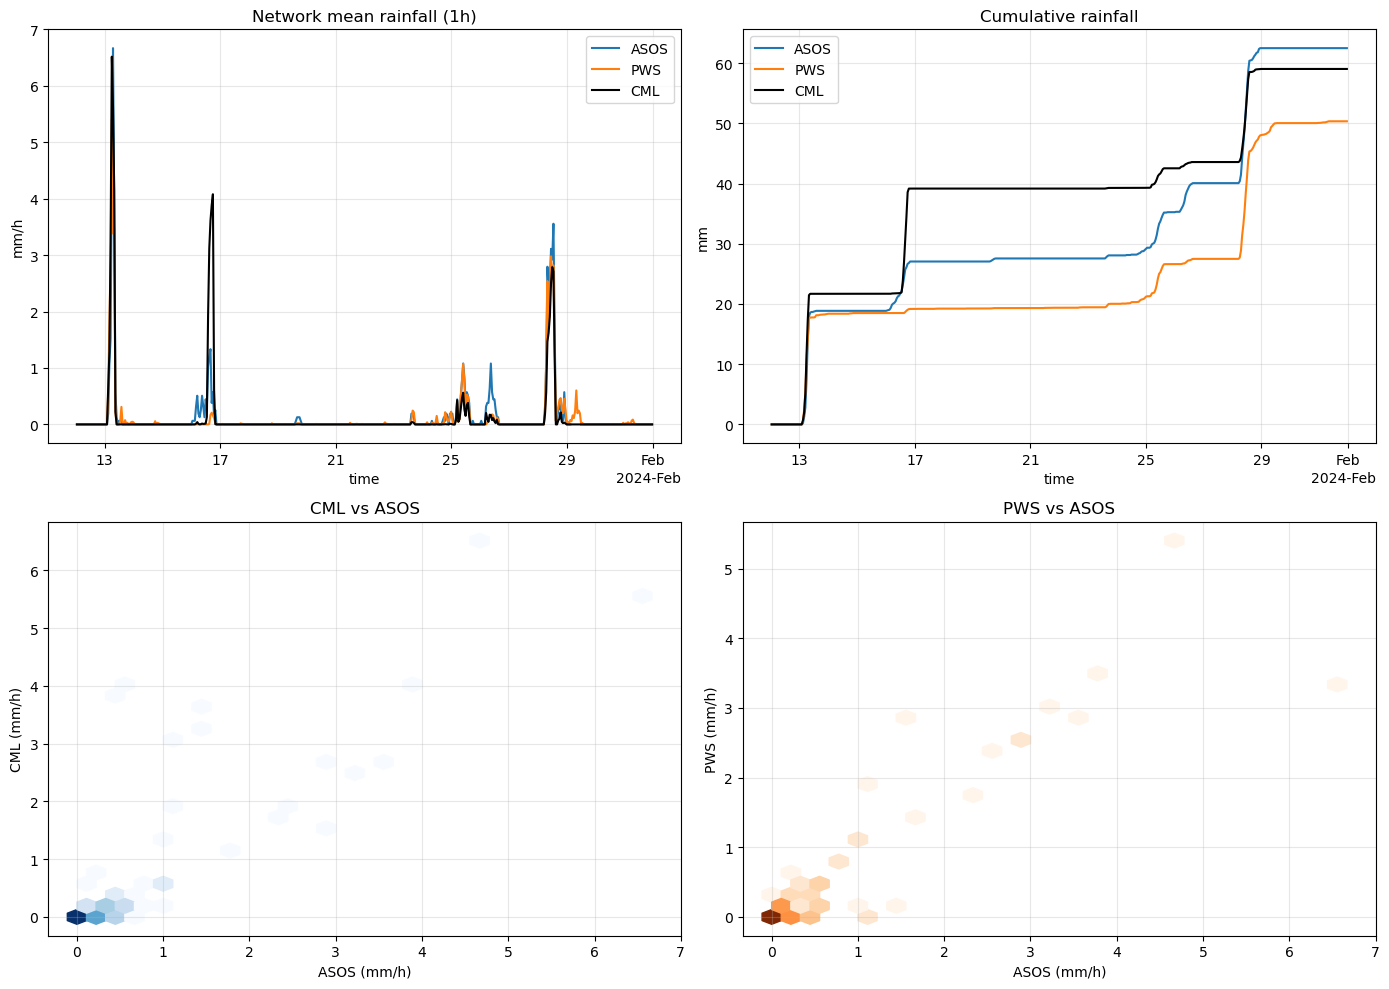

In [87]:
# ── config ────────────────────────────────────────────────────
RESAMPLE = "1h"  # common aggregation for all sensors

# common time window
t0 = max(pd.Timestamp(ds_cmls.time.values[0]),  pd.Timestamp(ds_pws.time.values[0]),  pd.Timestamp(ds_asos.time.values[0]))
t1 = min(pd.Timestamp(ds_cmls.time.values[-1]), pd.Timestamp(ds_pws.time.values[-1]), pd.Timestamp(ds_asos.time.values[-1]))

cml_r  = ds_cmls_filtered.R.resample(time=RESAMPLE).mean().mean(dim=["cml_id","sublink_id"], skipna=True).sel(time=slice(t0,t1))
pws_r  = ds_pws["rainfall_amount_qc"].resample(time=RESAMPLE).sum(skipna=True).mean(dim="id", skipna=True).sel(time=slice(t0,t1))
asos_r = ds_asos["rainfall_amount"].resample(time=RESAMPLE).sum(skipna=True).mean(dim="id", skipna=True).sel(time=slice(t0,t1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── time series ───────────────────────────────────────────────
ax = axes[0, 0]
asos_r.plot(ax=ax, label="ASOS", linewidth=1.5)
pws_r.plot(ax=ax,  label="PWS",  linewidth=1.5)
cml_r.plot(ax=ax,  label="CML",  linewidth=1.5, color="black")
ax.set(title=f"Network mean rainfall ({RESAMPLE})", ylabel="mm/h")
ax.legend(); ax.grid(True, alpha=0.3)

# ── cumulative ────────────────────────────────────────────────
ax = axes[0, 1]
asos_r.cumsum().plot(ax=ax, label="ASOS", linewidth=1.5)
pws_r.cumsum().plot(ax=ax,  label="PWS",  linewidth=1.5)
cml_r.cumsum().plot(ax=ax,  label="CML",  linewidth=1.5, color="black")
ax.set(title="Cumulative rainfall", ylabel="mm")
ax.legend(); ax.grid(True, alpha=0.3)

# ── CML vs ASOS hexbin ────────────────────────────────────────
ax = axes[1, 0]
ax.hexbin(asos_r.values, cml_r.values, gridsize=30, bins="log", cmap="Blues")
ax.set(title="CML vs ASOS", xlabel="ASOS (mm/h)", ylabel="CML (mm/h)")
ax.grid(True, alpha=0.3)

# ── PWS vs ASOS hexbin ───────────────────────────────────────
ax = axes[1, 1]
ax.hexbin(asos_r.values, pws_r.values, gridsize=30, bins="log", cmap="Oranges")
ax.set(title="PWS vs ASOS", xlabel="ASOS (mm/h)", ylabel="PWS (mm/h)")
ax.grid(True, alpha=0.3)

plt.tight_layout();

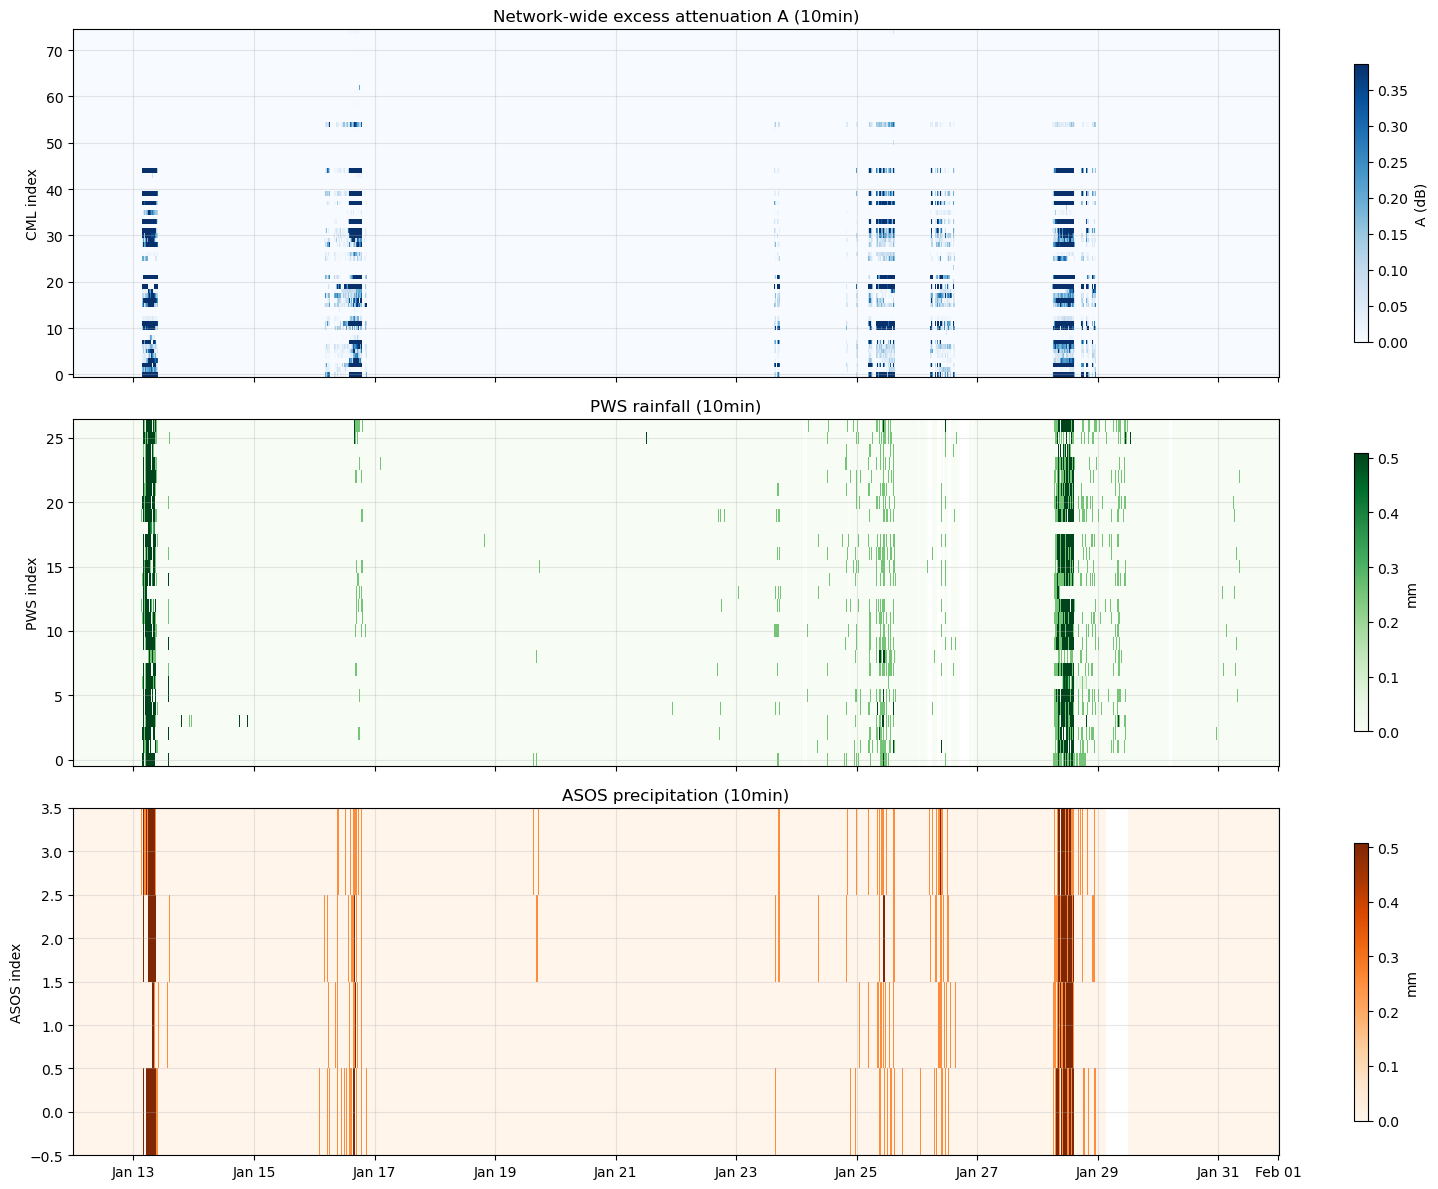

In [88]:
RESAMPLE = "10min"

A_da      = ds_cmls["A"].mean(dim="sublink_id").resample(time=RESAMPLE).mean()
pws_plot  = ds_pws["rainfall_amount_qc"].resample(time=RESAMPLE).sum(skipna=True)
asos_plot = ds_asos["rainfall_amount"].resample(time=RESAMPLE).sum(skipna=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

im0 = axes[0].pcolormesh(A_da.time.values, np.arange(A_da.sizes["cml_id"]),
                          A_da.values, cmap="Blues",
                          vmin=0, vmax=float(np.nanpercentile(A_da.values, 99)))
plt.colorbar(im0, ax=axes[0], label="A (dB)", shrink=0.8)
axes[0].set(ylabel="CML index", title=f"Network-wide excess attenuation A ({RESAMPLE})")

im1 = axes[1].pcolormesh(pws_plot.time.values, np.arange(pws_plot.sizes["id"]),
                          pws_plot.values, cmap="Greens",
                          vmin=0, vmax=float(np.nanpercentile(pws_plot.values, 99)))
plt.colorbar(im1, ax=axes[1], label="mm", shrink=0.8)
axes[1].set(ylabel="PWS index", title=f"PWS rainfall ({RESAMPLE})")

im2 = axes[2].pcolormesh(asos_plot.time.values, np.arange(asos_plot.sizes["id"]),
                          asos_plot.values, cmap="Oranges",
                          vmin=0, vmax=float(np.nanpercentile(asos_plot.values, 99)))
plt.colorbar(im2, ax=axes[2], label="mm", shrink=0.8)
axes[2].set(ylabel="ASOS index", title=f"ASOS precipitation ({RESAMPLE})")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout();

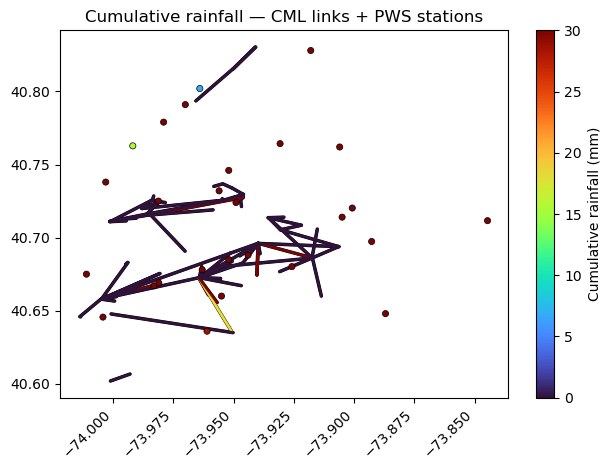

In [89]:
plg.plot_map.plot_plg(
    da_cmls=ds_cmls_filtered.isel(sublink_id=0).R.resample(time="1h").mean().sum(dim="time"),
    da_gauges=ds_pws["rainfall_amount_qc"].resample(time="1h").sum(skipna=True).sum(dim="time"),
    vmin=0,
    vmax=30,
    cmap="turbo",
    colorbar_label="Cumulative rainfall (mm)",
)
plt.title("Cumulative rainfall — CML links + PWS stations")
plt.gcf().autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

---

## Cross-Dataset Validation: CML vs. ASOS

### Nearest ASOS Station per CML

For each CML midpoint we find the nearest ASOS station using `pyproj`.


### CML Attenuation vs. ASOS Rainfall

Hourly mean attenuation A for CMLs nearest to the wettest ASOS station,
compared against the station's hourly rainfall. Both aggregated via
xarray `.resample()`.

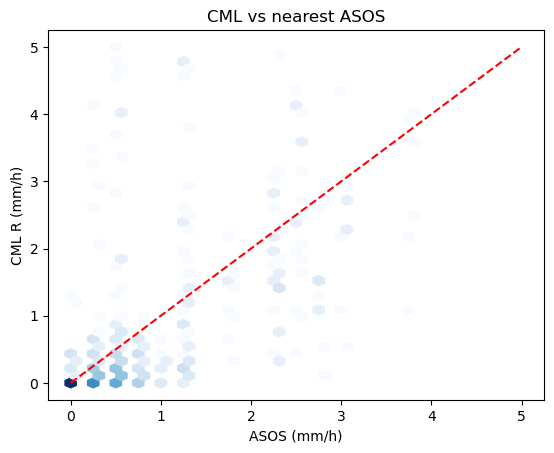

In [93]:
ds_asos_proj = prf.convert_to_utm(ds_asos.drop_vars("quantile", errors="ignore"),
                                   name_coord_lon="lon", name_coord_lat="lat", zone=18)

ds_cmls.coords["site_0_x"], ds_cmls.coords["site_0_y"] = plg.spatial.project_point_coordinates(ds_cmls.site_0_lon, ds_cmls.site_0_lat, "EPSG:32618")
ds_cmls.coords["site_1_x"], ds_cmls.coords["site_1_y"] = plg.spatial.project_point_coordinates(ds_cmls.site_1_lon, ds_cmls.site_1_lat, "EPSG:32618")

closest  = plg.spatial.get_closest_points_to_line(ds_cmls, ds_asos_proj, max_distance=20000, n_closest=1)
R_1h     = ds_cmls_filtered.R.isel(sublink_id=0).resample(time="1h").mean()

asos_1h  = ds_asos["rainfall_amount"].resample(time="1h").sum(skipna=True)

pairs = [(R_1h.sel(cml_id=c).values, asos_1h.sel(id=closest.sel(cml_id=c).neighbor_id.values[0])
          .reindex(time=R_1h.time, method="nearest").values)
         for c in closest.cml_id.values if closest.sel(cml_id=c).neighbor_id.values[0] is not None]

R_all, asos_all = [np.concatenate([p[i] for p in pairs]) for i in [0, 1]]
mask = ~np.isnan(R_all) & ~np.isnan(asos_all)

plt.hexbin(asos_all[mask], R_all[mask], gridsize=40, bins="log", cmap="Blues", extent=[0, 5, 0, 5])
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("ASOS (mm/h)"); plt.ylabel("CML R (mm/h)"); plt.title("CML vs nearest ASOS");


---

## Save Processed Datasets


In [91]:
save = False

if save:
    samples_dir = omio.SAMPLE_DIR
    samples_dir.mkdir(parents=True, exist_ok=True)

    t0 = pd.Timestamp(ds_cmls.time.values[0])
    t1 = pd.Timestamp(ds_cmls.time.values[-1])
    nd = max(1, int(np.ceil((t1 - t0).total_seconds() / 86400)))
    tag = f"{nd}d_{t0.strftime('%Y%m%d')}_{t1.strftime('%Y%m%d')}"

    omio.save_compressed_netcdf(ds_cmls, samples_dir / f"openmesh_cml_{tag}_processed.nc")
    omio.save_compressed_netcdf(ds_pws,  samples_dir / f"openmesh_wu_pws_{tag}_qc.nc")
    omio.save_compressed_netcdf(ds_asos, samples_dir / f"openmesh_asos_ws_{tag}_reference.nc")

    print("Saved to", samples_dir.resolve())


---

## Summary

> **Usage example only.** This notebook is intended as a demonstration of how to work with the OpenMesh datasets. Parameters, thresholds, and methods should be adapted for real analysis.

This notebook demonstrated how to:

1. **Download** the OpenMesh CML and PWS datasets from Zenodo programmatically
2. **Load** all three datasets with a single unified function
3. **Explore** the CML network structure, RSL signal levels, frequency/polarization distribution, and data availability
4. **Map** the CML network and PWS stations using `poligrain` (`scatter_lines`, `plot_lines`, `plot_plg`)
5. **QC** CML data by removing sentinel values and implausible outliers
6. **Compute** baseline RSL using `pycomlink` (rolling or constant method)
7. **Derive** excess attenuation $A = \mathrm{RSL_{baseline}} - \mathrm{RSL}$ and rain rate $R$
8. **Filter** CML links by length and frequency band
9. **Check** PWS data availability per station
10. **Apply QC** to PWS data using `pypwsqc` (FZ, HI, peak removal, and IC filters)
11. **Fetch** NOAA ASOS reference data via the IEM API and convert to xarray
12. **Compare** all three sources (CML, PWS, ASOS) over a common time window
13. **Validate** CML attenuation against the nearest ASOS reference station
14. **Save** processed datasets as compressed NetCDF using `omio.save_compressed_netcdf`